# Aprendizaje por refuerzo DQN
**Proyecto PAPIME PE104425 "Visualización animada en 3D de Redes Neuronales"**

**Fuentes:**

- [Reinforcement Learning (DQN) Tutorial](https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html)
- [Gymnasium Documentation - Basic Usage](https://gymnasium.farama.org/introduction/basic_usage/)

In [10]:
# Dependencias
#!pip3 install gymnasium[classic_control]

In [11]:
from IPython import display

## Escenario

In [12]:
import gymnasium as gym

In [13]:
import matplotlib
import matplotlib.pyplot as plt

### Ilustremos

**Referencia:** [Gymnasium Documentation - Env](https://gymnasium.farama.org/api/env/#gymnasium.Env.render)

Acciones: ['izquierda', 'derecha']
  Hay 2 acciones posibles codificadas como int64

Observaciones: ['posición del carro', 'velocidad del carro', 'ángulo del poste', 'velocidad angular del poste']
El espacio de obsevaciones contiene (4,) datos de tipo float32
    con límites inferiores [-4.8               -inf -0.41887903        -inf]
    y límites superiores   [4.8               inf 0.41887903        inf]

Estado inicial observado: ['posición del carro', 'velocidad del carro', 'ángulo del poste', 'velocidad angular del poste'] = [-0.02607535 -0.02111492 -0.00686976  0.04656028]


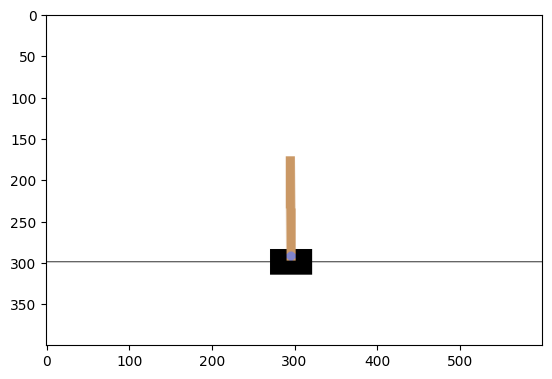

In [30]:
# Crea el ambiente
env = gym.make("CartPole-v1", render_mode="rgb_array")


# Acciones
#  Acciones de dos tipos:
#  0 = mover el carro a la izquierda
#  1 = mover el carro a la derecha
#  dtype('int64')
action_space = env.action_space
action_names = ["izquierda", "derecha"]
print(f"Acciones: {action_names}")
print(f"  Hay {action_space.n} acciones posibles codificadas como {action_space.dtype}")
print()


# Observaciones
observation_space = env.observation_space
observation_names = ["posición del carro", "velocidad del carro", "ángulo del poste", "velocidad angular del poste"]
print(f"Observaciones: {observation_names}")
print(f"""El espacio de obsevaciones contiene {observation_space.shape} datos de tipo {observation_space.dtype}
    con límites inferiores {observation_space.low}
    y límites superiores   {observation_space.high}""")
print()

# Reinicia el ambiente para inciar un episodio
state, info = env.reset()
print(f"Estado inicial observado: {observation_names} = {state}")
image = env.render()
plt.imshow(image)
env.close()

### Una escena completa

In [36]:
# Crea el ambiente
env = gym.make("CartPole-v1", render_mode="human")

# Reinicia el ambiente para inciar un episodio
state, info = env.reset()

print("Episodio 1")
print(f"    Acción   Estado: {observation_names}   Recompensa")

episode_over = False
total_reward = 0
paso = 0

while not episode_over:

    action = env.action_space.sample()  # Elige una acción al azar

    # Ejecuta la acción y ve qué pasa
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{paso:3d}    {action}                 {observation}                                                 {reward}")

    # recompensa: +1 si el poste aún está vertical
    # terminated: True si el poste se cae (el agente falla)
    # truncated: True si llegamos al final de episodio (500 pasos)

    total_reward += reward
    paso += 1
    episode_over = terminated or truncated

print(f"Fin del episodio.  Recompensa total obtenida: {total_reward}")
plt.pause(1)  # Esperamos un poco para observar el estado final
env.close()

Episodio 1
    Acción   Estado: ['posición del carro', 'velocidad del carro', 'ángulo del poste', 'velocidad angular del poste']   Recompensa
  0    1                 [ 0.01723206  0.16119663 -0.01942504 -0.3037562 ]                                                 1.0
  1    0                 [ 0.02045599 -0.03364318 -0.02550016 -0.01726225]                                                 1.0
  2    1                 [ 0.01978313  0.16183501 -0.02584541 -0.31788045]                                                 1.0
  3    0                 [ 0.02301983 -0.03290947 -0.03220302 -0.03345899]                                                 1.0
  4    0                 [ 0.02236164 -0.22755517 -0.0328722   0.24889214]                                                 1.0
  5    1                 [ 0.01781053 -0.03197957 -0.02789436 -0.05397546]                                                 1.0
  6    0                 [ 0.01717094 -0.22669068 -0.02897386  0.22977771]                      